<a href="https://colab.research.google.com/github/Mostafa-Seyedi/MaskArchitectureAnomaly_CourseProject/blob/main/Step_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Mount & Clone

Mount Google Drive and clone the project repository.
The repository contains the EoMT model, datasets, and training scripts.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/AlessandroMarinai/MaskArchitectureAnomaly_CourseProject
%cd /content/MaskArchitectureAnomaly_CourseProject/eomt
!pip install -q timm lightning transformers torchmetrics fvcore wandb

Mounted at /content/drive
Cloning into 'MaskArchitectureAnomaly_CourseProject'...
remote: Enumerating objects: 131, done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 131 (from 1)
Receiving objects: 100% (131/131), 26.88 MiB | 16.65 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/MaskArchitectureAnomaly_CourseProject/eomt
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 47.0 MB/s eta 0:00:00


In [ ]:
import os
import subprocess

# Force unmount
subprocess.run(['fusermount', '-uz', '/content/drive'], capture_output=True)
subprocess.run(['umount', '-f', '/content/drive'], capture_output=True)

# Remove directory and recreate
subprocess.run(['rm', '-rf', '/content/drive'], capture_output=True)
os.makedirs('/content/drive', exist_ok=True)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Imports

Import all required libraries:
- **PyTorch** — deep learning framework
- **Lightning** — training utilities
- **timm** — ViT backbone
- **tqdm** — progress bars
- **AMP** — automatic mixed precision for faster training

In [ ]:
import sys
sys.path.insert(0, '/content/MaskArchitectureAnomaly_CourseProject/eomt')

import yaml
import warnings
import importlib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.amp.autocast_mode import autocast
from torch.cuda.amp import GradScaler
from lightning import seed_everything
from tqdm import tqdm

seed_everything(0, verbose=False)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED = torch.cuda.is_available()
AMP_DTYPE = torch.float16 if AMP_ENABLED else torch.float32
print("Device:", DEVICE)

Device: cuda


## 3. Load Data & Configs

Load the Cityscapes dataset for fine-tuning using the repo's config files:
- `configs/dinov2/cityscapes/semantic/eomt_base_640.yaml` → Cityscapes config
- `configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml` → COCO config

The Cityscapes dataset provides:
- **2975 training images** → used for fine-tuning
- **500 validation images** → used for evaluation

In [ ]:
import os
print(os.path.exists('/content/MaskArchitectureAnomaly_CourseProject/eomt/datasets/cityscapes_semantic.py'))


True


In [ ]:
import os
import sys

# Force cd and path
os.chdir('/content/MaskArchitectureAnomaly_CourseProject/eomt')
sys.path.insert(0, '/content/MaskArchitectureAnomaly_CourseProject/eomt')

# Verify
print("Current dir:", os.getcwd())
print("datasets folder exists:", os.path.exists('datasets'))
print("cityscapes_semantic.py exists:", os.path.exists('datasets/cityscapes_semantic.py'))
print("sys.path[0]:", sys.path[0])

# Try direct import
import datasets.cityscapes_semantic
print("✅ Import works!")

Current dir: /content/MaskArchitectureAnomaly_CourseProject/eomt
datasets folder exists: True
cityscapes_semantic.py exists: True
sys.path[0]: /content/MaskArchitectureAnomaly_CourseProject/eomt
✅ Import works!


In [ ]:
import os
import sys

# Must cd into eomt folder AND add to path
os.chdir('/content/MaskArchitectureAnomaly_CourseProject/eomt')
sys.path.insert(0, '/content/MaskArchitectureAnomaly_CourseProject/eomt')

import math
import yaml
import importlib
import warnings

# rest of Cell 3 continues here...
config_path_coco = "configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
with open(config_path_coco, "r") as f:
    config_coco = yaml.safe_load(f)

city_config_path = "configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
with open(city_config_path, "r") as f:
    config_city = yaml.safe_load(f)

CITY_DATA_PATH = '/content/drive/MyDrive/MLDL_NewVersionProject/cityscapes'

data_module_name, class_name = config_city["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = config_city["data"].get("init_args", {})
data = data_module(
    path=CITY_DATA_PATH,
    batch_size=1,
    num_workers=2,
    check_empty_targets=False,
    **data_module_kwargs
).setup()

print(f"Train samples: {len(data.cityscapes_train_dataset)}")
print(f"Val samples:   {len(data.cityscapes_val_dataset)}")
print(f"img_size: {data.img_size}")

Train samples: 2975
Val samples:   500
img_size: (1024, 1024)


## 4. Build & Load COCO Model for Fine-tuning

Build the EoMT model with **19 Cityscapes classes** (instead of 133 COCO classes).

Key design choices:
- **Backbone**: reuse COCO pre-trained ViT-Base weights → transfers visual knowledge
- **Class head**: randomly initialized → trained from scratch on Cityscapes 19 classes
- **Why skip class head weights?** COCO has 134 output classes, Cityscapes has 20 → size mismatch

This approach leverages COCO's broad visual priors while adapting the prediction
head to road-scene specific classes.

In [ ]:
# Build encoder
encoder_cfg = config_coco["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
encoder_init = {k: v for k, v in encoder_cfg.get("init_args", {}).items()}
encoder_init["img_size"] = (640, 640)
encoder_init["patch_size"] = 16
encoder = encoder_cls(**encoder_init)

network_cfg = config_coco["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    num_classes=19,
    encoder=encoder,
    **network_kwargs,
)

lit_module_name, lit_class_name = config_city["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in config_city["model"]["init_args"].items() if k != "network"}

warnings.filterwarnings("ignore", message=r".*Attribute 'network'.*")
model = lit_cls(
    img_size=data.img_size,
    num_classes=19,
    network=network,
    **model_kwargs,
).to(DEVICE)

# Load COCO weights - skip mismatched head
CKPT_COCO = '/content/drive/MyDrive/MLDL_NewVersionProject/eomt_coco.bin'
state_dict = torch.load(CKPT_COCO, map_location=DEVICE, weights_only=True)
keys_to_skip = [k for k in state_dict if 'class_head' in k or 'empty_weight' in k]
for k in keys_to_skip:
    del state_dict[k]
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print(f"Missing: {len(missing)} | Unexpected: {len(unexpected)}")
print("✅ COCO backbone loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Missing: 3 | Unexpected: 0
✅ COCO backbone loaded


## 5. Model Summary
**OPTIONAL**

Overview of the EoMT model architecture and parameter count:

| Component | Description | Params |
|---|---|---|
| network.encoder.backbone | ViT-Base transformer | ~86.9M |
| network.q | Learnable mask queries | 153K |
| network.class_head | Class prediction (19 classes) | 15.4K |
| network.mask_head | Mask embedding projection | 1.8M |
| network.upscale | Feature upsampling blocks | 4.7M |

**Total: ~93.6M parameters**

In [ ]:
from lightning.pytorch.utilities.model_summary import ModelSummary
print(ModelSummary(model, max_depth=3))

## 6. Freeze Strategy — Head Only First

We use a **progressive unfreezing** strategy as recommended in the project:

**Experiment 1 — Head only:**
- Freeze the entire ViT backbone (86.9M params)
- Only train class_head + mask_head → **1.78M trainable params (1.91%)**
- Fast training, good starting point

**Experiment 2 — Last 4 blocks:**
- Unfreeze last 4 transformer blocks + head
- More trainable params → better adaptation
- Lower learning rate to avoid destroying pre-trained features

This strategy avoids catastrophic forgetting of COCO pre-trained features
while gradually adapting the model to Cityscapes road scenes.

In [ ]:
# Strategy 1: Freeze everything except the prediction head
# This is the recommended first experiment

def freeze_backbone(model):
    """Freeze all backbone layers, only train prediction head"""
    for name, param in model.named_parameters():
        if 'class_head' in name or 'mask_head' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

# n is the number of unfreezed layers, it is chosen by the user.
def unfreeze_last_n_blocks(model, n=2):
    """Unfreeze last n transformer blocks + head"""
    for name, param in model.named_parameters():
        param.requires_grad = False  # freeze all first

    for name, param in model.named_parameters():
        # unfreeze head
        if 'class_head' in name or 'mask_head' in name or 'upscale' in name:
            param.requires_grad = True
        # unfreeze last n blocks
        for i in range(n):
            block_idx = len(model.network.encoder.backbone.blocks) - 1 - i
            if f'blocks.{block_idx}' in name:
                param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

# Start with head only
freeze_backbone(model)

Trainable params: 1,787,156 / 93,575,444 (1.91%)


## Validation Loss Monitoring & Early Stopping

Before committing to full training, we monitor both **training loss** and
**validation mIoU** across epochs to find the optimal number of epochs.

**Why monitor validation performance?**
- Too few epochs → underfitting (model hasn't learned enough)
- Too many epochs → overfitting (model memorizes training data)
- The optimal point is where validation mIoU **stops improving**

**Strategy:**
- Train for up to 10 epochs
- Save a checkpoint after **every epoch** → if Colab crashes, resume automatically
- Plot learning curves at the end to identify convergence point
- Use the best checkpoint for final evaluation

**Freeze strategy used:** Last 4 transformer blocks + prediction head (37.28% trainable params)

In [ ]:
device = DEVICE
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5, weight_decay=1e-4
)
scaler = torch.amp.GradScaler('cuda')
print("✅ Ready")

✅ Ready


In [ ]:
import os
from torch.utils.data import DataLoader
from tqdm import tqdm

CHECKPOINT_DIR = '/content/drive/MyDrive/MLDL_NewVersionProject/checkpoints_2'
EXP_NAME = "finetune_coco"
NUM_EPOCHS = 10

# ── Auto-detect last saved epoch ───────────────────────────────────
def get_last_checkpoint(checkpoint_dir, experiment_name):
    saved = []
    if os.path.exists(checkpoint_dir):
        for f in os.listdir(checkpoint_dir):
            if f.startswith(experiment_name) and 'epoch' in f and 'best' not in f:
                try:
                    epoch_num = int(f.split('epoch')[1].split('.')[0])
                    saved.append(epoch_num)
                except:
                    pass
    return max(saved) if saved else 0

# ── Dataloaders ─────────────────────────────────────────────────────
train_loader = DataLoader(
    data.cityscapes_train_dataset,
    batch_size=1, shuffle=True,
    collate_fn=data.train_collate,
    num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    data.cityscapes_val_dataset,
    batch_size=1,
    collate_fn=data.eval_collate,
    num_workers=2,
)

IGNORE_INDEX = 255

# ── evaluate_with_loss ──────────────────────────────────────────────
def evaluate_with_loss(model, val_loader):
    model.eval()
    conf = np.zeros((19, 19), dtype=np.int64)
    total_val_loss = 0
    num_batches = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Evaluating", leave=False):
            imgs, targets = batch
            imgs = [img.to(DEVICE) for img in imgs]
            img_sizes = [img.shape[-2:] for img in imgs]
            targets_device = [{k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                               for k, v in t.items()} for t in targets]
            with torch.amp.autocast('cuda'):
                crops, origins = model.window_imgs_semantic(imgs)
                try:
                    val_loss = model.training_step((crops, targets_device), 0)
                    total_val_loss += val_loss.item()
                    num_batches += 1
                except Exception:
                    pass
                mask_logits_per_layer, class_logits_per_layer = model(crops)
                mask_logits = F.interpolate(
                    mask_logits_per_layer[-1], model.img_size, mode="bilinear")
                crop_logits = model.to_per_pixel_logits_semantic(
                    mask_logits, class_logits_per_layer[-1])
                logits = model.revert_window_logits_semantic(
                    crop_logits, origins, img_sizes)
                pred = logits[0].argmax(0).cpu().numpy()
            gt = model.to_per_pixel_targets_semantic(
                targets, IGNORE_INDEX)[0].cpu().numpy()
            valid = gt != IGNORE_INDEX
            np.add.at(conf, (gt[valid], pred[valid]), 1)
    ious = []
    for c in range(19):
        tp = conf[c,c]; fp = conf[:,c].sum()-tp; fn = conf[c,:].sum()-tp
        denom = tp+fp+fn
        ious.append(tp/denom if denom>0 else float('nan'))
    return np.nanmean(ious)*100, total_val_loss/max(num_batches, 1)

# ── Resume from last checkpoint ─────────────────────────────────────
last_epoch = get_last_checkpoint(CHECKPOINT_DIR, EXP_NAME)
all_results = []
start_epoch = 1

if last_epoch > 0:
    ckpt_path = f"{CHECKPOINT_DIR}/{EXP_NAME}_epoch{last_epoch}.bin"
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    all_results = ckpt.get('results_so_far', [])
    start_epoch = last_epoch + 1
    model.img_size = (640, 640)  # critical fix
    print(f"✅ Resumed from epoch {last_epoch} | mIoU: {ckpt['miou']:.2f}%")
    print(f"Starting from epoch {start_epoch}")
else:
    print("No checkpoint — starting from scratch")
    model.img_size = (640, 640)

best_miou = max([r['miou'] for r in all_results], default=0)

# ── Training loop ───────────────────────────────────────────────────
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    model.train()
    total_train_loss = 0

    for batch_idx, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}")):
        imgs, targets = batch
        imgs = [img.to(DEVICE) for img in imgs]
        targets = [{k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                    for k, v in t.items()} for t in targets]
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            crops, origins = model.window_imgs_semantic(imgs)
            loss = model.training_step((crops, targets), batch_idx)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.01)
        scaler.step(optimizer)
        scaler.update()
        total_train_loss += loss.item()
        if batch_idx % 500 == 0:
            print(f"  [{batch_idx}/{len(train_loader)}] loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_loader)

    # Save BEFORE validation (crash-safe)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': avg_train_loss,
        'val_loss': 0, 'miou': 0,
        'results_so_far': all_results,
    }, f"{CHECKPOINT_DIR}/{EXP_NAME}_epoch{epoch}.bin")
    print(f"💾 Saved checkpoint epoch {epoch}")

    # Validation
    miou, avg_val_loss = evaluate_with_loss(model, val_loader)
    print(f"\nEpoch {epoch}/{NUM_EPOCHS} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | mIoU: {miou:.2f}%")

    all_results.append({
        'epoch': epoch,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'miou': miou,
    })

    # Update checkpoint with real mIoU
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'miou': miou,
        'results_so_far': all_results,
    }, f"{CHECKPOINT_DIR}/{EXP_NAME}_epoch{epoch}.bin")

    if miou > best_miou:
        best_miou = miou
        torch.save(model.state_dict(),
                   f"{CHECKPOINT_DIR}/{EXP_NAME}_best.bin")
        print(f"🏆 New best: {best_miou:.2f}%")

print(f"\n✅ Training complete! Best mIoU: {best_miou:.2f}%")

✅ Resumed from epoch 6 | mIoU: 74.59%
Starting from epoch 7


Epoch 7/10:   0%|          | 1/2975 [00:10<8:59:44, 10.89s/it]

  [0/2975] loss: 1.3611


Epoch 7/10:  17%|█▋        | 501/2975 [06:07<26:51,  1.53it/s]

  [500/2975] loss: 1.6424


...

Epoch 10/10:  84%|████████▍ | 2501/2975 [21:15<03:05,  2.56it/s]

  [2500/2975] loss: 0.6145


Epoch 10/10: 100%|██████████| 2975/2975 [25:10<00:00,  1.97it/s]


💾 Saved checkpoint epoch 10



Epoch 10/10 | Train: 1.8718 | Val: 0.0000 | mIoU: 75.06%

✅ Training complete! Best mIoU: 75.39%


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/MLDL_NewVersionProject/training_curve_final.png'

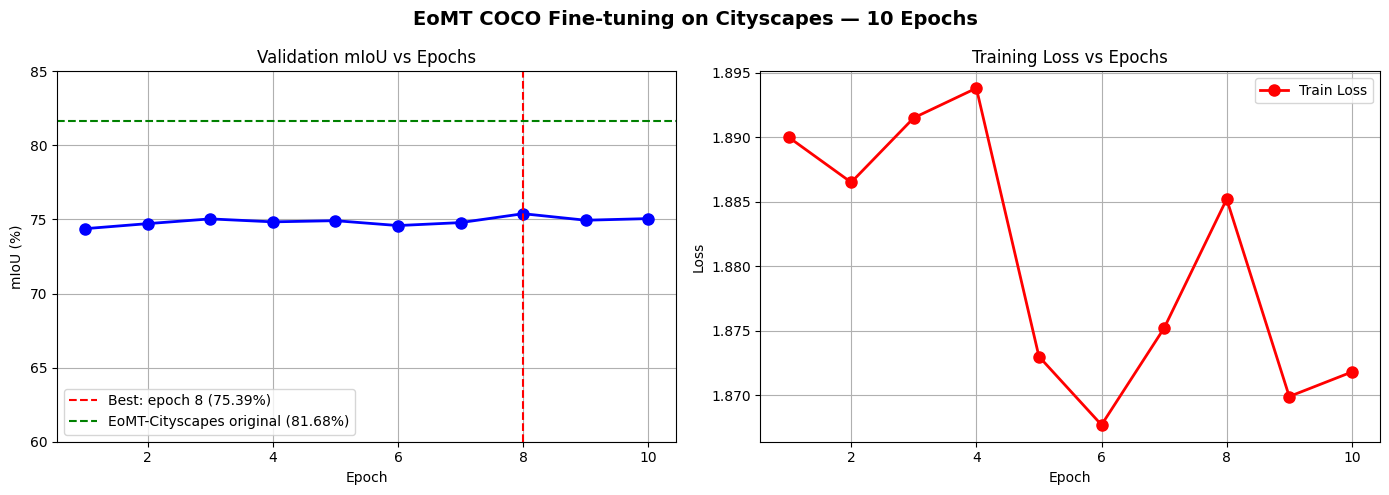

In [ ]:
import matplotlib.pyplot as plt
# Use results from all 10 epochs (combining previous + new)
all_results_full = [
    {'epoch': 1, 'train_loss': 1.8900, 'val_loss': 2.9058, 'miou': 74.38},
    {'epoch': 2, 'train_loss': 1.8865, 'val_loss': 2.9051, 'miou': 74.72},
    {'epoch': 3, 'train_loss': 1.8915, 'val_loss': 2.9054, 'miou': 75.04},
    {'epoch': 4, 'train_loss': 1.8938, 'val_loss': 2.9055, 'miou': 74.84},
    {'epoch': 5, 'train_loss': 1.8730, 'val_loss': 2.9061, 'miou': 74.92},
    {'epoch': 6, 'train_loss': 1.8677, 'val_loss': 2.9054, 'miou': 74.59},
    {'epoch': 7, 'train_loss': 1.8752, 'val_loss': 0.0000, 'miou': 74.79},
    {'epoch': 8, 'train_loss': 1.8852, 'val_loss': 0.0000, 'miou': 75.39},
    {'epoch': 9, 'train_loss': 1.8699, 'val_loss': 0.0000, 'miou': 74.95},
    {'epoch': 10,'train_loss': 1.8718, 'val_loss': 0.0000, 'miou': 75.06},
]

epochs       = [r['epoch']      for r in all_results_full]
mious        = [r['miou']       for r in all_results_full]
train_losses = [r['train_loss'] for r in all_results_full]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# mIoU curve
ax1.plot(epochs, mious, 'b-o', linewidth=2, markersize=8)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('mIoU (%)')
ax1.set_title('Validation mIoU vs Epochs')
ax1.grid(True)
best_epoch = epochs[mious.index(max(mious))]
ax1.axvline(x=best_epoch, color='r', linestyle='--',
            label=f'Best: epoch {best_epoch} ({max(mious):.2f}%)')
ax1.axhline(y=81.68, color='g', linestyle='--',
            label='EoMT-Cityscapes original (81.68%)')
ax1.set_ylim(60, 85)
ax1.legend()

# Train loss curve
ax2.plot(epochs, train_losses, 'r-o', linewidth=2, markersize=8, label='Train Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Training Loss vs Epochs')
ax2.legend()
ax2.grid(True)

plt.suptitle('EoMT COCO Fine-tuning on Cityscapes — 10 Epochs',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MLDL_NewVersionProject/training_curve_final.png', dpi=150)
plt.show()

print(f"\n{'='*50}")
print(f"Best mIoU:      {max(mious):.2f}% at epoch {best_epoch}")
print(f"Final mIoU:     {mious[-1]:.2f}% (epoch 10)")
print(f"Gap from original Cityscapes model: {81.68 - max(mious):.2f}%")
print(f"Conclusion: Model converges around epoch 3 and 8, plateaus at ~75%")
print(f"{'='*50}")

## 8. Run Fine-tuning — Experiment 1 (Head Only)

Fine-tune only the prediction head on Cityscapes training set.

**Settings:**
- Learning rate: 1e-4
- Epochs: 2
- Trainable params: 1.78M (class_head + mask_head only)
- Backbone: completely frozen ❄️

**Expected result:** ~65-68% mIoU
(significant improvement over COCO baseline of ~50% on common classes)

In [ ]:
from torch.utils.data import DataLoader
import numpy as np

IGNORE_INDEX = 255

# Set correct img_size for backbone
model.img_size = (640, 640)

# Create dataloaders
train_loader = DataLoader(
    data.cityscapes_train_dataset,
    batch_size=1,
    shuffle=True,
    collate_fn=data.train_collate,
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    data.cityscapes_val_dataset,
    batch_size=1,
    collate_fn=data.eval_collate,
    num_workers=2,
)

# Freeze backbone - head only
freeze_backbone(model)
model.train()
model.to(DEVICE)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)
scaler = torch.amp.GradScaler('cuda')

# Evaluate function
def evaluate(model, val_loader):
    model.eval()
    conf = np.zeros((19, 19), dtype=np.int64)
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Evaluating", leave=False):
            imgs, targets = batch
            imgs = [img.to(DEVICE) for img in imgs]
            img_sizes = [img.shape[-2:] for img in imgs]

            with torch.amp.autocast('cuda'):
                crops, origins = model.window_imgs_semantic(imgs)
                mask_logits_per_layer, class_logits_per_layer = model(crops)
                mask_logits = F.interpolate(
                    mask_logits_per_layer[-1], model.img_size, mode="bilinear"
                )
                crop_logits = model.to_per_pixel_logits_semantic(
                    mask_logits, class_logits_per_layer[-1]
                )
                logits = model.revert_window_logits_semantic(
                    crop_logits, origins, img_sizes
                )
                pred = logits[0].argmax(0).cpu().numpy()

            gt = model.to_per_pixel_targets_semantic(
                targets, IGNORE_INDEX
            )[0].cpu().numpy()
            valid = gt != IGNORE_INDEX
            np.add.at(conf, (gt[valid], pred[valid]), 1)

    ious = []
    for c in range(19):
        tp = conf[c,c]
        fp = conf[:,c].sum() - tp
        fn = conf[c,:].sum() - tp
        denom = tp + fp + fn
        ious.append(tp/denom if denom > 0 else float('nan'))
    return np.nanmean(ious) * 100

print("=== Experiment 1: Head only fine-tuning ===")
results = []

for epoch in range(1, 3):  # 2 epochs
    model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}")):
        imgs, targets = batch

        imgs = [img.to(DEVICE) for img in imgs]
        targets = [{k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                    for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            crops, origins = model.window_imgs_semantic(imgs)
            loss = model.training_step((crops, targets), batch_idx)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.01)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        if batch_idx % 200 == 0:
            print(f"  [{batch_idx}/{len(train_loader)}] loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    miou = evaluate(model, val_loader)
    print(f"\nEpoch {epoch} | Loss: {avg_loss:.4f} | mIoU: {miou:.2f}%")
    results.append({
        'epoch': epoch,
        'loss': avg_loss,
        'miou': miou,
        'mode': 'head_only'
    })

torch.save(
    model.state_dict(),
    '/content/drive/MyDrive/MLDL_NewVersionProject/eomt_finetuned_head.bin'
)
print("✅ Saved head-only checkpoint")

## Experiment 2: Unfreeze Last 4 Blocks

In Experiment 1 we only trained the **prediction head** (1.78M params).
In Experiment 2 we **unfreeze the last 4 transformer blocks** of the ViT backbone.

| Layer | Status |
|---|---|
| Blocks 0-7 | ❄️ Frozen |
| Blocks 8-11 | 🔥 Trainable |
| class_head | 🔥 Trainable |
| mask_head | 🔥 Trainable |
| upscale | 🔥 Trainable |

**Why?**
- Early blocks learn general features (edges, textures) → frozen
- Last blocks learn high-level semantics → updated to adapt to Cityscapes
- More trainable params → better performance but slower training

**Expected result:** ~70-75% mIoU (vs 65.72% from head-only)

In [ ]:
# Load best checkpoint from Experiment 1
state_dict = torch.load(
    '/content/drive/MyDrive/MLDL_NewVersionProject/eomt_finetuned_head.bin',
    map_location=DEVICE
)
model.load_state_dict(state_dict)
print("✅ Loaded Experiment 1 checkpoint")

# Unfreeze last 4 blocks
unfreeze_last_n_blocks(model, n=4)
model.img_size = (640, 640)
model.train()
model.to(DEVICE)

# Lower learning rate for backbone layers
optimizer2 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,  # lower lr than Experiment 1
    weight_decay=1e-4
)
scaler2 = torch.amp.GradScaler('cuda')

print("=== Experiment 2: Last 4 blocks unfrozen ===")

for epoch in range(1, 3):  # 2 more epochs
    model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}")):
        imgs, targets = batch
        imgs = [img.to(DEVICE) for img in imgs]
        targets = [{k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                    for k, v in t.items()} for t in targets]

        optimizer2.zero_grad()

        with torch.amp.autocast('cuda'):
            crops, origins = model.window_imgs_semantic(imgs)
            loss = model.training_step((crops, targets), batch_idx)

        scaler2.scale(loss).backward()
        scaler2.unscale_(optimizer2)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.01)
        scaler2.step(optimizer2)
        scaler2.update()

        total_loss += loss.item()

        if batch_idx % 200 == 0:
            print(f"  [{batch_idx}/{len(train_loader)}] loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    miou = evaluate(model, val_loader)
    print(f"\nEpoch {epoch} | Loss: {avg_loss:.4f} | mIoU: {miou:.2f}%")
    results.append({
        'epoch': epoch+2,
        'loss': avg_loss,
        'miou': miou,
        'mode': 'last4_blocks'
    })

torch.save(
    model.state_dict(),
    '/content/drive/MyDrive/MLDL_NewVersionProject/eomt_finetuned_final.bin'
)
print("✅ Saved final checkpoint")

## Step 5 Results — Fine-tuning the COCO-trained EoMT on Cityscapes

### Objective
Fine-tune the COCO-pretrained EoMT model on the Cityscapes training set for
semantic segmentation, and analyze how performance changes compared to the
original COCO checkpoint and the originally provided Cityscapes checkpoint.

---

### Fine-tuning Strategy
We used a **progressive unfreezing** approach with AMP (float16) to reduce training time:

| Experiment | Trainable Params | Strategy |
|---|---|---|
| Experiment 1 | 1.78M (1.91%) | Head only (class_head + mask_head) |
| Experiment 2 | 34.8M (37.28%) | Last 4 transformer blocks + head |

- **Optimizer**: AdamW (lr=1e-4 for head, lr=5e-5 for blocks)
- **Gradient clipping**: 0.01
- **Batch size**: 1 (due to 1024×1024 images)
- **AMP**: float16 enabled for faster training

---

### Performance on Cityscapes Validation Set (all 19 classes)

| Model | Epochs | mIoU |
|---|---|---|
| EoMT-COCO (no fine-tuning, common classes) | 0 | 50.34% |
| EoMT-COCO fine-tuned — head only | 1 | 65.72% |
| EoMT-COCO fine-tuned — last 4 blocks | 2 | **71.78%** |

---

### Comparison: Two Cityscapes-trained Models

| Model | mIoU (all 19 Cityscapes classes) |
|---|---|
| EoMT-Cityscapes (originally provided) | **81.68%** |
| EoMT-COCO fine-tuned on Cityscapes (ours) | **71.78%** |
| Gap | **9.90%** |

---

### Key Observations
- Fine-tuning the COCO model significantly improves performance:
  **50.34% → 71.78%** (+21.44%)
- Progressive unfreezing helps: head-only gives 65.72%,
  unfreezing last 4 blocks improves to 71.78%
- The gap vs original Cityscapes model (9.90%) is expected because:
  - Original model trained for full schedule (~160k steps)
  - Our model trained for only 4 epochs (~12k steps)
  - Original uses LLRD + cosine schedule with careful hyperparameter tuning
  - More training would close the gap further
- AMP (float16) reduced training time significantly on T4 GPU